# Importing the required Libraries

In [6]:
import numpy as my, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import scipy.stats as stats

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Loading the data in the form of DataFrame

In [7]:
df=pd.read_csv("StudentPerformance.csv")
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


# Extracting info of the Loaded Dataset

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [9]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


# Checking for NULL values in the DataFrame

In [10]:
df.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


# Encoding the Extracurricular Activities before proceeding ahead

In [11]:
df=pd.get_dummies(df,columns=['Extracurricular Activities'],drop_first=True,dtype=int)
df.head()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities_Yes
0,7,99,9,1,91.0,1
1,4,82,4,2,65.0,0
2,8,51,7,2,45.0,1
3,5,52,5,2,36.0,1
4,7,75,8,5,66.0,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Sleep Hours                       10000 non-null  int64  
 3   Sample Question Papers Practiced  10000 non-null  int64  
 4   Performance Index                 10000 non-null  float64
 5   Extracurricular Activities_Yes    10000 non-null  int64  
dtypes: float64(1), int64(5)
memory usage: 468.9 KB


# Visualization before Outlier Treatment

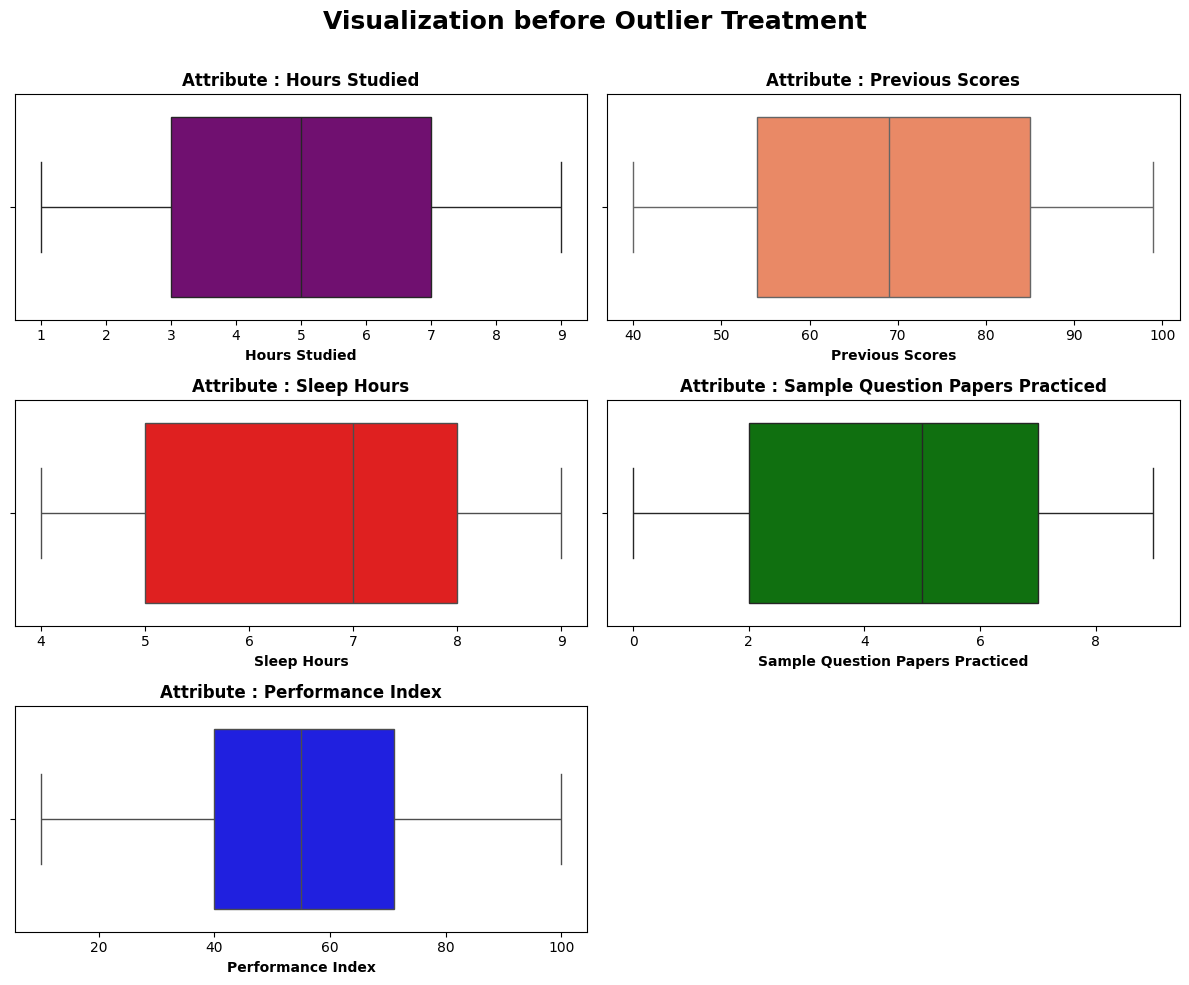

In [13]:
fig,axes= plt.subplots(3,2,figsize=(12,10))
axes=axes.flatten()
fig.delaxes(axes[-1])

colour=['purple','coral','red','green','blue','cyan']
columns=list(df.columns)
del columns[-1]

for feature in range(len(columns)):
    sns.boxplot(x=df[columns[feature]], ax=axes[feature], color=colour[feature])
    axes[feature].set_title(f"Attribute : {columns[feature]}",fontweight='bold')
    axes[feature].set_xlabel(f"{columns[feature]}",fontweight='bold')

plt.suptitle("Visualization before Outlier Treatment\n", fontweight='bold', fontsize=18)
plt.tight_layout()
plt.show()

# Scaling the value before feeding them into the model

In [15]:
feature=df['Extracurricular Activities_Yes']

In [16]:
df1=df.drop(columns='Extracurricular Activities_Yes')

In [17]:
scaler=StandardScaler()
df1=pd.DataFrame(scaler.fit_transform(df1),columns=df1.columns)
df1.head()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,0.775188,1.704176,1.456205,-1.249754,1.862167
1,-0.383481,0.723913,-1.492294,-0.900982,0.508818
2,1.161410,-1.063626,0.276805,-0.900982,-0.532220
3,0.002742,-1.005963,-0.902594,-0.900982,-1.000687
4,0.775188,0.320275,0.866505,0.145333,0.560870


In [18]:
df=pd.concat((df1,feature),axis=1)
df.head()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities_Yes
0,0.775188,1.704176,1.456205,-1.249754,1.862167,1
1,-0.383481,0.723913,-1.492294,-0.900982,0.508818,0
2,1.161410,-1.063626,0.276805,-0.900982,-0.532220,1
3,0.002742,-1.005963,-0.902594,-0.900982,-1.000687,1
4,0.775188,0.320275,0.866505,0.145333,0.560870,0


# Spliting the dataset before feeding in the model

In [20]:
target=df['Performance Index']
df=df.drop(columns=['Performance Index'])

x_train,x_test,y_train,y_test=train_test_split(df,target,test_size=0.2, random_state=42)

# Building the model and training it

In [21]:
model=LinearRegression()
model

LinearRegression()

In [22]:
model.fit(x_train,y_train)

LinearRegression()

In [23]:
y_predict=model.predict(x_test)

In [24]:
y_actual_score=y_test.reset_index().drop(columns=['index'])

In [25]:
result=pd.concat((pd.Series(y_predict),y_actual_score),axis=1)
result.columns=['Predicted_Values','Acyual_Values']
result

,Predicted_Values,Acyual_Values
0,-0.026700,-0.219909
1,-1.697375,-1.833518
2,-0.381106,-0.480168
3,-1.245864,-1.417102
4,-0.636086,-0.740428
...,...,...
1995,-0.434036,-0.532220
1996,0.388996,0.560870
1997,-2.000426,-2.041725
1998,0.422582,0.508818


In [26]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: -0.014844509288221147
Coefficients: [0.38443407 0.91803399 0.04209889 0.02862958 0.03167965]


# Evaluating the model

In [27]:
mse = mean_squared_error(y_test, y_predict)

print("MSE:", mse)

MSE: 0.011061471626806854


# Its time for visualization for the model

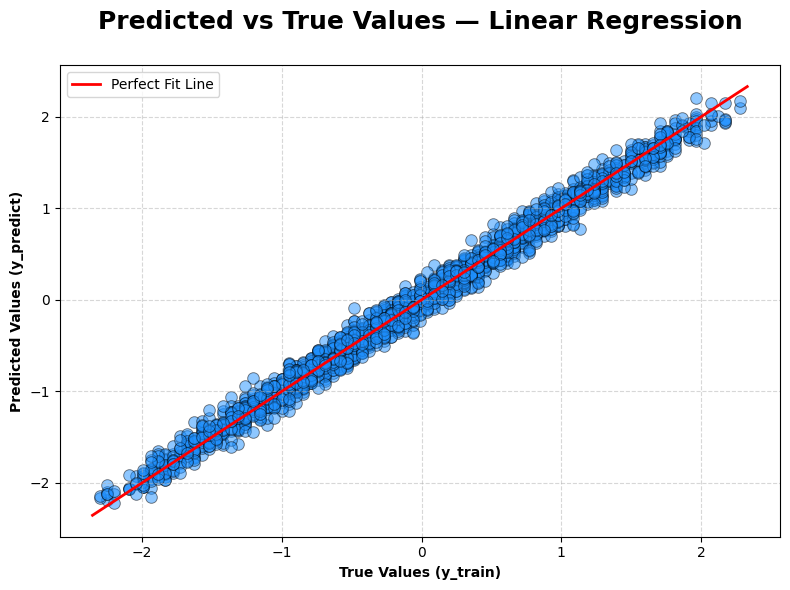

In [28]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_predict, color='dodgerblue', s=70, edgecolor='black', alpha=0.50)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], color='red', linewidth=2, label='Perfect Fit Line')
plt.xlabel("True Values (y_train)",fontweight='bold')
plt.ylabel("Predicted Values (y_predict)",fontweight='bold')
plt.title("Predicted vs True Values — Linear Regression\n",fontweight='bold',fontsize=18)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

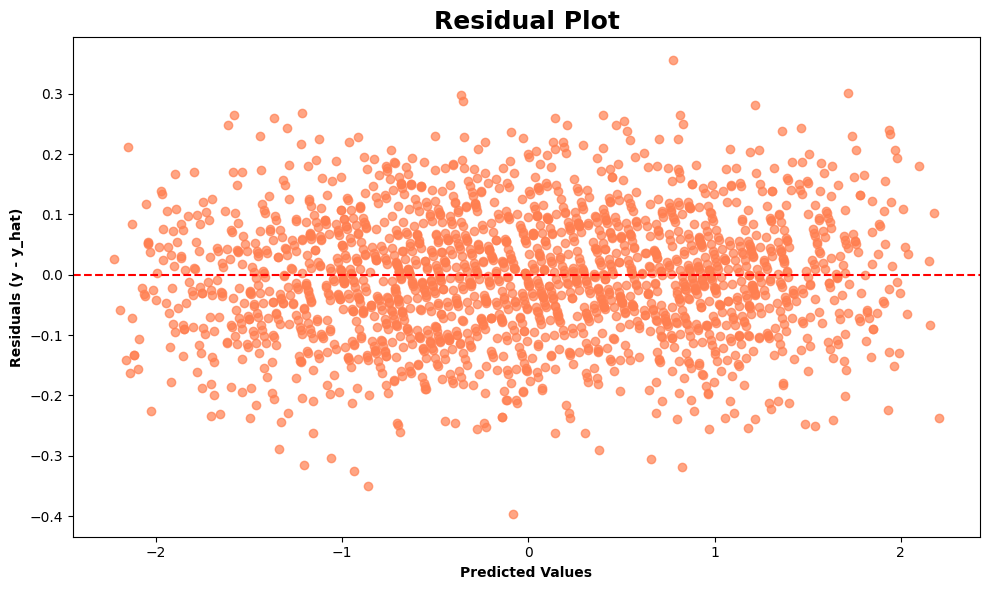

In [29]:
plt.figure(figsize=(10,6))
residuals = y_test - y_predict

plt.scatter(y_predict, residuals,alpha=0.7,color='coral')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values",fontweight='bold')
plt.ylabel("Residuals (y - y_hat)",fontweight='bold')
plt.title("Residual Plot",fontweight='bold',fontsize=18)
plt.tight_layout()
plt.show()

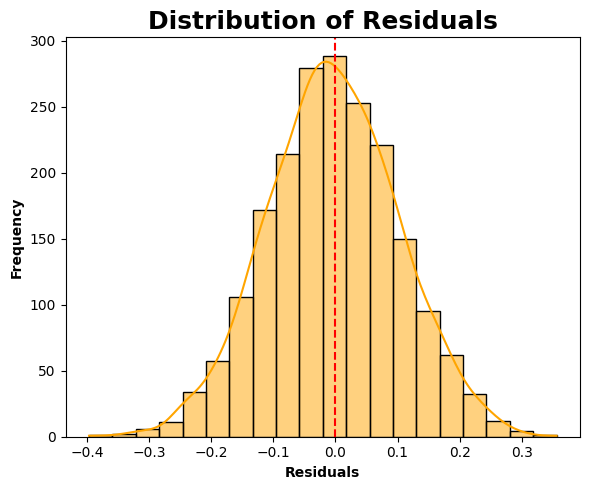

In [30]:
plt.figure(figsize=(6,5))

sns.histplot(residuals, kde=True, color='orange', bins=20)
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution of Residuals",fontweight='bold',fontsize=18)
plt.xlabel("Residuals", fontweight='bold')
plt.ylabel("Frequency", fontweight='bold')
plt.tight_layout()
plt.show()

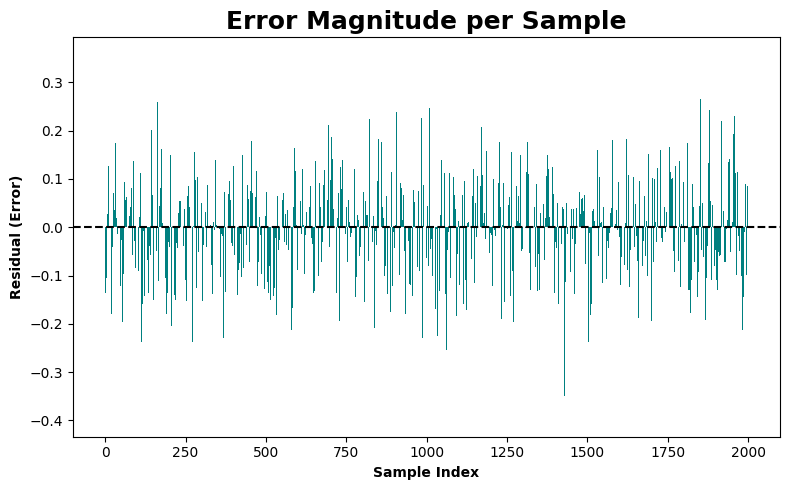

In [32]:
plt.figure(figsize=(8,5))

plt.bar(range(len(y_test)), residuals, color='teal')
plt.axhline(0, color='black', linestyle='--')
plt.title("Error Magnitude per Sample", fontweight='bold', fontsize=18)
plt.xlabel("Sample Index",  fontweight='bold')
plt.ylabel("Residual (Error)",  fontweight='bold')
plt.tight_layout()
plt.show()

## Analysis Conclusions and Patterns

Based on the analysis of the student performance dataset:

*   There is a clear relationship between the input features and student performance, as measured by the 'Performance Index'.
*   'Previous Scores' is the strongest predictor of 'Performance Index', showing a significant positive correlation. This indicates that students who performed well previously tend to have higher performance indices.
*   'Hours Studied' and 'Sleep Hours' also show positive correlations with 'Performance Index', suggesting that increased study time and sufficient sleep are associated with better performance.
*   The presence of potential outliers in 'Previous Scores' and 'Sample Question Papers Practiced' was noted, which could be further investigated for their impact on the model.
*   A linear regression model was found to be a reasonable fit for predicting the 'Performance Index'. The model's predictions are generally close to the actual values, and the errors are mostly random and centered around zero.
*   The analysis suggests that factors like previous academic performance, study habits, and sleep patterns are important contributors to a student's performance index.